In [1]:
# Install if not already installed
!pip install tensorflow matplotlib

# Imports
import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

Defaulting to user installation because normal site-packages is not writeable


2026-04-30 11:31:45.243316: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-30 11:31:45.277256: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
train_dir = "dataset/train"
test_dir = "dataset/test"

img_size = (224, 224)
batch_size = 32

train_data = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    image_size=img_size,
    batch_size=batch_size
)

test_data = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    image_size=img_size,
    batch_size=batch_size
)

Found 800 files belonging to 2 classes.
Found 200 files belonging to 2 classes.


In [3]:
normalization_layer = layers.Rescaling(1./255)

train_data = train_data.map(lambda x, y: (normalization_layer(x), y))
test_data = test_data.map(lambda x, y: (normalization_layer(x), y))

In [4]:
base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze layers (important for transfer learning)
for layer in base_model.layers:
    layer.trainable = False

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step 


In [5]:
model = models.Sequential([
    base_model,
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

In [6]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [7]:
history = model.fit(
    train_data,
    validation_data=test_data,
    epochs=5
)

Epoch 1/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 19s 738ms/step - accuracy: 0.6500 - loss: 0.9451 - val_accuracy: 0.8750 - val_loss: 0.3078
Epoch 2/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 20s 728ms/step - accuracy: 0.8687 - loss: 0.2987 - val_accuracy: 0.9050 - val_loss: 0.2530
Epoch 3/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 19s 651ms/step - accuracy: 0.9250 - loss: 0.1806 - val_accuracy: 0.9200 - val_loss: 0.2359
Epoch 4/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 22s 733ms/step - accuracy: 0.9500 - loss: 0.1334 - val_accuracy: 0.8950 - val_loss: 0.2382
Epoch 5/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 16s 653ms/step - accuracy: 0.9688 - loss: 0.0971 - val_accuracy: 0.9000 - val_loss: 0.2316


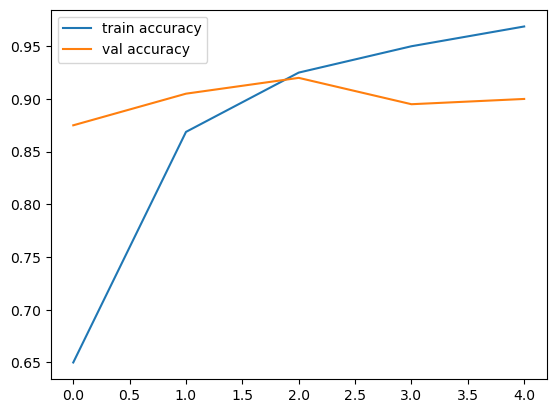

In [8]:
plt.plot(history.history['accuracy'], label='train accuracy')
plt.plot(history.history['val_accuracy'], label='val accuracy')
plt.legend()
plt.show()